# CIFAR-10 CNN — Part B (Claude Code) results

Loads `results/part_b_results.csv` and `results/history/*.csv` and renders one table + curves per
study (BatchNorm/Dropout, depth, activation), plus an A-vs-B comparison when Part A results exist.

Run `python run_experiments.py` first to generate the results.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().parents[0] if Path.cwd().name == 'ai_generated' else Path.cwd()
RESULTS = REPO / 'results'
HIST = RESULTS / 'history'
FIG = RESULTS / 'figures'
FIG.mkdir(exist_ok=True)

df = pd.read_csv(RESULTS / 'part_b_results.csv')
df

,experiment_set,run_name,num_blocks,use_bn,dropout,activation,num_params,epochs,train_time_s,final_train_loss,final_val_loss,best_val_acc,test_acc
0,bn_dropout,reg_none,3,False,0.0,relu,814122,25,418.2,0.4127,0.4842,0.8314,0.8347
1,bn_dropout,reg_dropout_only,3,False,0.5,relu,814122,25,396.1,0.4979,0.5191,0.8186,0.8182
2,bn_dropout,reg_bn_only,3,True,0.0,relu,814570,25,413.2,0.1745,0.3260,0.8928,0.8872
3,bn_dropout,reg_bn_dropout,3,True,0.5,relu,814570,25,415.7,0.2552,0.3362,0.8856,0.8826
4,depth,depth_1block,1,True,0.5,relu,2110186,25,255.7,1.0875,0.8313,0.7048,0.7042
5,depth,depth_2block,2,True,0.5,relu,1117162,25,366.0,0.5858,0.4774,0.8296,0.8271
6,depth,depth_3block,3,True,0.5,relu,814570,25,497.7,0.2552,0.3362,0.8856,0.8826
7,depth,depth_4block,4,True,0.5,relu,1438186,25,543.3,0.1667,0.3326,0.8956,0.8923
8,activation,act_relu,3,True,0.5,relu,814570,25,522.0,0.2552,0.3362,0.8856,0.8826
9,activation,act_leaky_relu,3,True,0.5,leaky_relu,814570,25,470.8,0.2333,0.3482,0.8842,0.8827


In [2]:
def load_hist(run_name):
    return pd.read_csv(HIST / f'{run_name}.csv')

def curve_plot(run_names, title, fname):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for rn in run_names:
        h = load_hist(rn)
        ax[0].plot(h['epoch'], h['val_loss'], label=rn)
        ax[1].plot(h['epoch'], h['val_acc'], label=rn)
    ax[0].set(title=f'{title} — val loss', xlabel='epoch', ylabel='loss')
    ax[1].set(title=f'{title} — val acc', xlabel='epoch', ylabel='acc')
    for a in ax:
        a.legend(); a.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(FIG / fname, dpi=120); plt.show()

## Study 1 — Batch Normalization & Dropout
Overfitting gap = final_train_loss − final_val_loss (more negative = more overfit).

,run_name,use_bn,dropout,num_params,test_acc,best_val_acc,overfit_gap
0,reg_none,False,0.0,814122,0.8347,0.8314,-0.0715
1,reg_dropout_only,False,0.5,814122,0.8182,0.8186,-0.0212
2,reg_bn_only,True,0.0,814570,0.8872,0.8928,-0.1515
3,reg_bn_dropout,True,0.5,814570,0.8826,0.8856,-0.0810


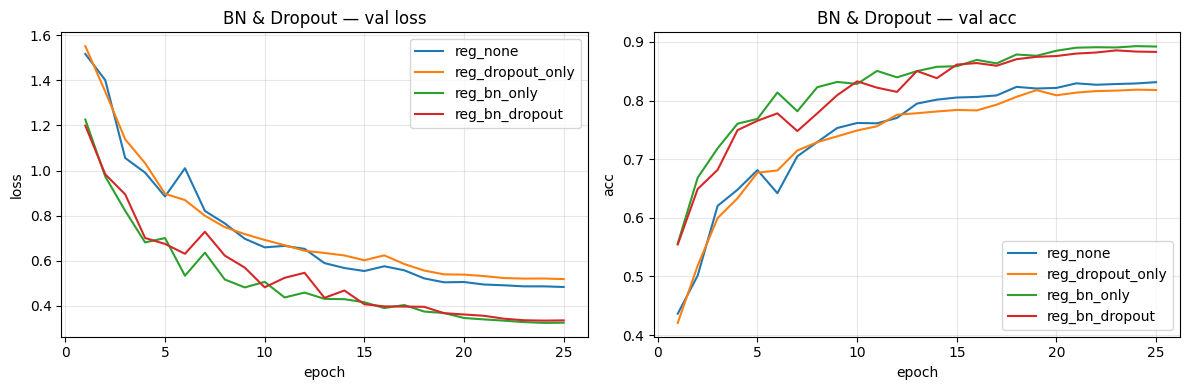

In [3]:
s1 = df[df.experiment_set == 'bn_dropout'].copy()
s1['overfit_gap'] = s1['final_train_loss'] - s1['final_val_loss']
display(s1[['run_name','use_bn','dropout','num_params','test_acc','best_val_acc','overfit_gap']])
curve_plot(s1['run_name'], 'BN & Dropout', 'study1_bn_dropout.png')

## Study 2 — Number of convolution/pooling layers

,run_name,num_blocks,num_params,train_time_s,test_acc,best_val_acc
4,depth_1block,1,2110186,255.7,0.7042,0.7048
5,depth_2block,2,1117162,366.0,0.8271,0.8296
6,depth_3block,3,814570,497.7,0.8826,0.8856
7,depth_4block,4,1438186,543.3,0.8923,0.8956


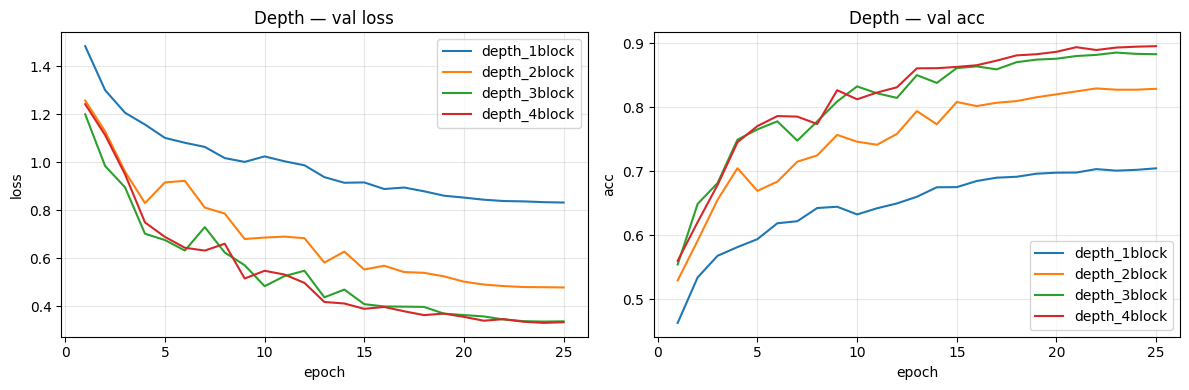

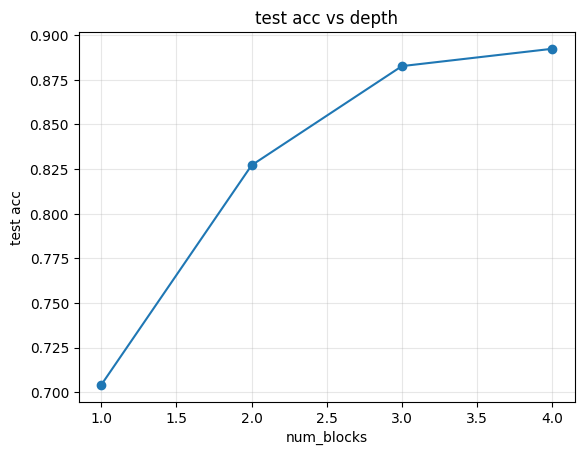

In [4]:
s2 = df[df.experiment_set == 'depth'].copy()
display(s2[['run_name','num_blocks','num_params','train_time_s','test_acc','best_val_acc']])
curve_plot(s2['run_name'], 'Depth', 'study2_depth.png')
ax = s2.plot(x='num_blocks', y='test_acc', marker='o', legend=False, title='test acc vs depth')
ax.set_ylabel('test acc'); ax.grid(alpha=0.3)

## Study 3 — Activation function

,run_name,activation,test_acc,best_val_acc,final_train_loss
8,act_relu,relu,0.8826,0.8856,0.2552
9,act_leaky_relu,leaky_relu,0.8827,0.8842,0.2333
10,act_elu,elu,0.8643,0.8750,0.3674
11,act_tanh,tanh,0.8255,0.8432,0.4796
12,act_sigmoid,sigmoid,0.7235,0.7312,0.8272


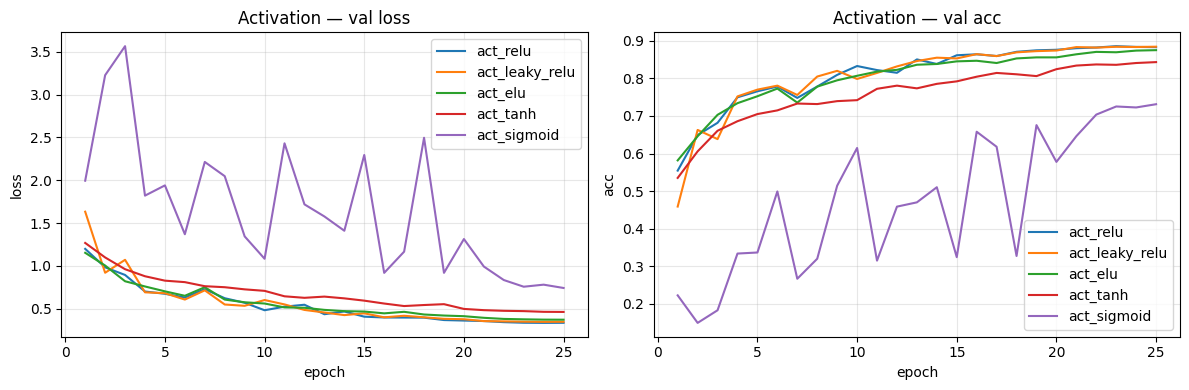

In [5]:
s3 = df[df.experiment_set == 'activation'].copy()
display(s3[['run_name','activation','test_acc','best_val_acc','final_train_loss']])
curve_plot(s3['run_name'], 'Activation', 'study3_activation.png')

### Bonus — Sigmoid without vs with BatchNorm (vanishing gradients)

,run_name,activation,use_bn,test_acc,final_train_loss
13,vg_sigmoid_no_bn,sigmoid,False,0.1000,2.3028
14,vg_sigmoid_bn,sigmoid,True,0.7235,0.8272


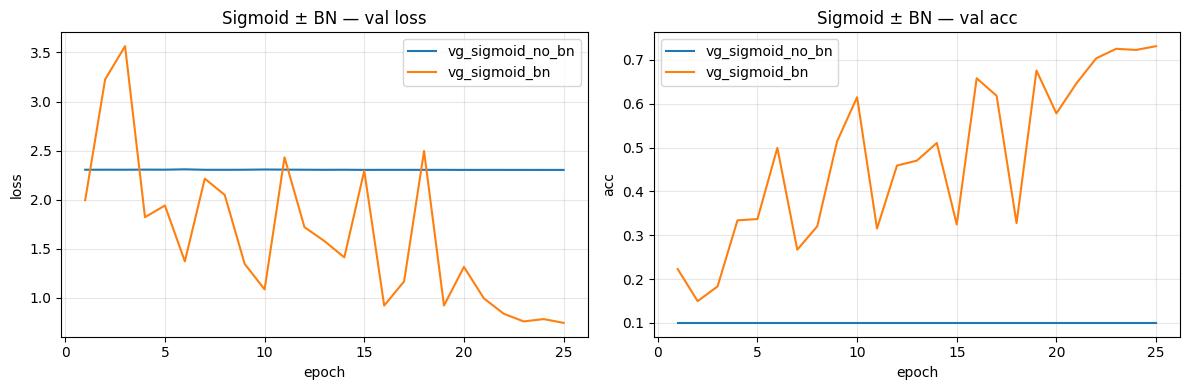

In [6]:
vg = df[df.experiment_set == 'vanishing'].copy()
display(vg[['run_name','activation','use_bn','test_acc','final_train_loss']])
curve_plot(vg['run_name'], 'Sigmoid ± BN', 'bonus_vanishing.png')

## manual vs ai_generated comparison
Compares the baseline (`part_a_results.csv`, folder `manual/`) against the optimized Claude Code
version (`part_b_results.csv`, folder `ai_generated/`), merged on `run_name`.

,run_name,experiment_set,ai_test_acc,manual_test_acc,ai_minus_manual
0,act_elu,activation,0.8643,0.7491,0.1152
1,act_leaky_relu,activation,0.8827,0.7456,0.1371
2,act_relu,activation,0.8826,0.7576,0.1250
3,act_sigmoid,activation,0.7235,0.5905,0.1330
4,act_tanh,activation,0.8255,0.7169,0.1086
5,depth_1block,depth,0.7042,0.6604,0.0438
6,depth_2block,depth,0.8271,0.7245,0.1026
7,depth_3block,depth,0.8826,0.7576,0.1250
8,depth_4block,depth,0.8923,0.7563,0.1360
9,reg_bn_dropout,bn_dropout,0.8826,0.7576,0.1250


mean improvement (ai - manual): 0.1076


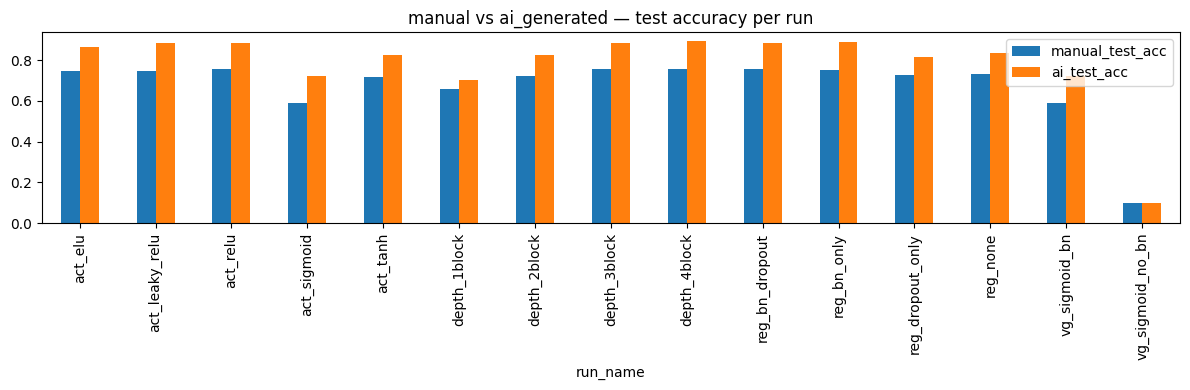

In [7]:
pa_path = RESULTS / 'part_a_results.csv'
if pa_path.exists():
    a = pd.read_csv(pa_path)[['run_name','test_acc']].rename(columns={'test_acc':'manual_test_acc'})
    b = df[['run_name','experiment_set','test_acc']].rename(columns={'test_acc':'ai_test_acc'})
    cmp = b.merge(a, on='run_name', how='outer')
    cmp['ai_minus_manual'] = cmp['ai_test_acc'] - cmp['manual_test_acc']
    display(cmp)
    print(f"mean improvement (ai - manual): {cmp['ai_minus_manual'].mean():.4f}")
    cmp.plot(x='run_name', y=['manual_test_acc','ai_test_acc'], kind='bar', figsize=(12,4),
             title='manual vs ai_generated — test accuracy per run')
    plt.tight_layout(); plt.savefig(FIG / 'compare_manual_vs_ai.png', dpi=120); plt.show()
else:
    print('part_a_results.csv not found yet — run manual/run_experiments.py to populate this section.')